In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join
from pathlib import Path
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from mylib import genomes

In [3]:
root_dir = join(Path.home(),"projects/cp_als/populations")

In [4]:
adf = pd.DataFrame(columns=genomes.keys())
for population_name in genomes:
    genome_ids = genomes[population_name]
    #print(population_name, len(genome_ids))
    df = pd.read_csv(join(root_dir,f"output/{population_name}/all.csv"))
    df = df[genomes[population_name]+["gene"]]
    variant_mean = df.groupby(['gene']).sum().mean(axis=1)
    adf[population_name] = variant_mean

# Remove ALS-associated genes before clustering
adf = adf.drop(index=["FUS", "SOD1", "TARDBP", "CHMP2B"], errors="ignore")

In [5]:
adf.head(10)

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,ESN,FIN,GBR,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
gene,,,,,,,,,,,,,,,,,,,,,
ALS2,110.793814,116.592593,125.244186,128.935484,126.794118,127.447619,118.223404,108.60,124.796117,121.197917,...,127.151515,112.408163,116.566667,118.444444,119.176471,125.937500,118.038462,122.931373,124.685185,112.529412
ANG,17.752577,18.777778,13.151163,14.172043,14.725490,13.533333,12.585106,18.45,15.864078,14.020833,...,13.595960,18.377551,17.788889,16.285714,17.717647,14.395833,15.057692,14.607843,15.583333,18.078431
ATXN2,170.020619,152.518519,63.604651,90.075269,92.411765,88.485714,70.308511,162.36,44.902913,46.843750,...,86.646465,171.928571,177.922222,71.666667,49.917647,63.770833,74.384615,62.990196,42.046296,175.607843
C19ORF12,28.752577,30.314815,22.744186,23.150538,23.519608,24.523810,22.255319,32.08,19.708738,17.489583,...,23.858586,28.132653,32.611111,22.428571,24.400000,22.166667,22.105769,22.303922,17.898148,31.490196
C9ORF72,41.010309,38.537037,45.895349,44.354839,43.441176,44.066667,43.340426,40.32,48.126214,45.645833,...,45.050505,36.938776,37.777778,46.476190,43.976471,47.927083,44.634615,46.607843,43.333333,40.039216
CHCHD10,7.938144,8.111111,6.209302,6.258065,5.911765,6.000000,7.670213,7.87,7.757282,7.541667,...,5.979798,7.846939,8.088889,7.301587,7.058824,6.468750,7.855769,6.509804,7.925926,8.068627
CHRNA3,45.216495,45.814815,44.686047,49.763441,50.598039,50.219048,43.851064,46.04,45.320388,43.177083,...,50.323232,48.918367,47.088889,41.904762,36.694118,45.072917,45.548077,42.990196,45.611111,47.333333
CREST,110.402062,94.981481,64.686047,60.129032,62.794118,54.171429,49.712766,113.61,44.524272,46.010417,...,64.909091,109.969388,113.988889,43.412698,42.105882,59.656250,51.019231,73.607843,45.212963,118.411765
DAO,35.711340,33.981481,25.162791,28.010753,30.892157,33.723810,29.021277,35.52,18.932039,18.906250,...,32.383838,36.959184,36.811111,34.015873,39.270588,26.729167,29.413462,25.754902,23.453704,36.352941


In [6]:
tdf = adf.transpose()

In [7]:
tdf

gene,ALS2,ANG,ATXN2,C19ORF12,C9ORF72,CHCHD10,CHRNA3,CREST,DAO,DCTN1,...,SETX,SIGMAR1,SPG11,SQSTM1,TAF15,TUBA4A,VAPB,VCP,hnRNPA2B1,hnRNPa1
ACB,110.793814,17.752577,170.020619,28.752577,41.010309,7.938144,45.216495,110.402062,35.711340,23.659794,...,197.886598,2.010309,51.185567,62.092784,24.845361,4.917526,63.474227,11.000000,5.154639,1.969072
ASW,116.592593,18.777778,152.518519,30.314815,38.537037,8.111111,45.814815,94.981481,33.981481,19.259259,...,193.351852,2.259259,47.870370,59.111111,27.703704,4.592593,55.870370,12.462963,5.351852,2.037037
BEB,125.244186,13.151163,63.604651,22.744186,45.895349,6.209302,44.686047,64.686047,25.162791,10.220930,...,192.383721,1.616279,35.395349,50.348837,22.453488,4.127907,44.383721,12.546512,3.523256,2.313953
CDX,128.935484,14.172043,90.075269,23.150538,44.354839,6.258065,49.763441,60.129032,28.010753,16.290323,...,220.870968,2.161290,47.322581,49.290323,24.043011,3.892473,62.892473,6.849462,5.387097,2.333333
CHB,126.794118,14.725490,92.411765,23.519608,43.441176,5.911765,50.598039,62.794118,30.892157,16.127451,...,208.352941,2.009804,45.186275,50.558824,26.950980,4.313725,49.735294,7.578431,5.509804,3.000000
CHS,127.447619,13.533333,88.485714,24.523810,44.066667,6.000000,50.219048,54.171429,33.723810,15.828571,...,217.457143,1.952381,48.152381,50.466667,23.704762,4.295238,51.847619,8.438095,6.152381,2.676190
CLM,118.223404,12.585106,70.308511,22.255319,43.340426,7.670213,43.851064,49.712766,29.021277,8.031915,...,144.297872,1.500000,18.617021,51.265957,16.521277,4.031915,41.585106,13.425532,3.702128,2.500000
ESN,108.600000,18.450000,162.360000,32.080000,40.320000,7.870000,46.040000,113.610000,35.520000,29.440000,...,208.260000,1.810000,54.340000,67.250000,30.040000,4.520000,71.090000,10.960000,5.920000,2.160000
FIN,124.796117,15.864078,44.902913,19.708738,48.126214,7.757282,45.320388,44.524272,18.932039,5.067961,...,129.883495,1.621359,17.038835,45.689320,16.233010,3.941748,66.660194,10.699029,2.815534,1.980583
GBR,121.197917,14.020833,46.843750,17.489583,45.645833,7.541667,43.177083,46.010417,18.906250,4.125000,...,135.302083,1.468750,15.947917,43.583333,14.781250,3.645833,54.281250,13.250000,2.500000,1.562500


In [8]:
features = tdf.values
labels = list(tdf.index)

# t-SNE 2D scatter plot

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


PALETTES = [
    ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"],
    ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D"],
    ["#2F5597", "#C00000", "#548235", "#7F6000", "#5F497A", "#1F4E79", "#3F3F3F"],
]

MARKERS = ["o", "s", "^", "D", "X", "P", "v"]


def plot_tsne_poster_population_legend(
    features,
    labels,
    lr=200,
    per=10,
    scaled=True,
    palette_id=0,
    out_dir="plots",
    filename_prefix="tsne_population",
    figsize=(12, 8),
):

    # -------------------------
    # Scaling
    # -------------------------
    if scaled:
        X = StandardScaler().fit_transform(features)
    else:
        X = features

    # -------------------------
    # t-SNE
    # -------------------------
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=per,
        learning_rate=lr
    )
    X_embedded = tsne.fit_transform(X)

    # -------------------------
    # Clustering
    # -------------------------
    n_clusters_map = {3: 5, 5: 4, 7: 3}
    if per not in n_clusters_map:
        raise ValueError(f"per={per} not supported")

    k = n_clusters_map[per]

    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    cluster_ids = agg.fit_predict(X_embedded)

    # -------------------------
    # Styling
    # -------------------------
    palette = PALETTES[palette_id % len(PALETTES)]
    cluster_colors = palette[:k]
    cluster_markers = MARKERS[:k]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # -------------------------
    # Scatter plot
    # -------------------------
    for c in range(k):
        idx = np.where(cluster_ids == c)[0]
        ax.scatter(
            X_embedded[idx, 0],
            X_embedded[idx, 1],
            c=cluster_colors[c],
            marker=cluster_markers[c],
            s=110,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.6,
            zorder=3
        )

    # -------------------------
    # Legend grouped by cluster (NOT alphabetical)
    # -------------------------
    handles = []

    for c in range(k):
        idxs = np.where(cluster_ids == c)[0]

        for i in idxs:  # preserve natural order inside cluster
            handles.append(
                Line2D(
                    [0], [0],
                    marker=cluster_markers[c],
                    linestyle="",
                    markerfacecolor=cluster_colors[c],
                    markeredgecolor="black",
                    markersize=9,
                    label=str(labels[i])
                )
            )

    # Make room for legend
    fig.subplots_adjust(right=0.72)

    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=12,
        handlelength=1.0,
        labelspacing=0.4
    )

    # -------------------------
    # Labels
    # -------------------------
    # ax.set_title(
    #     f"t-SNE (perplexity={per}, lr={lr})",
    #     fontsize=20,
    #     fontweight="bold"
    # )
    ax.set_xlabel("t-SNE 1", fontsize=16, fontweight="bold")
    ax.set_ylabel("t-SNE 2", fontsize=16, fontweight="bold")
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.25)

    # -------------------------
    # Save
    # -------------------------
    # os.makedirs(out_dir, exist_ok=True)
    # filename = f"{filename_prefix}_per{per}_lr{lr}_k{k}_palette{palette_id}.png"
    # path = os.path.join(out_dir, filename)

    # plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    # print(f"Plot saved as: {path}")
    # return path

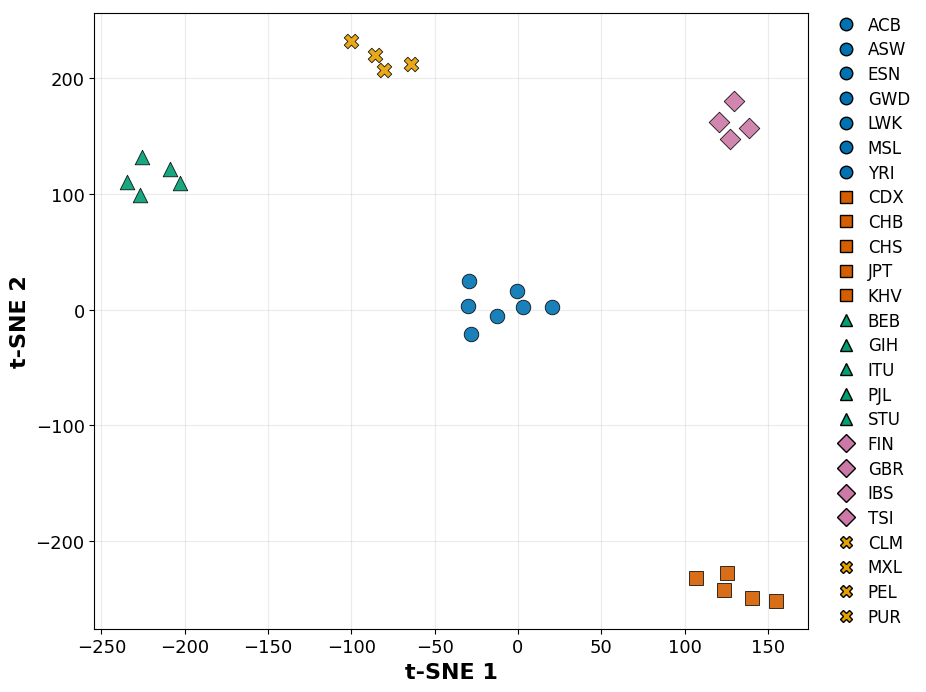

In [10]:
plot_tsne_poster_population_legend(features, labels, per=3, lr=200, palette_id=0, filename_prefix="tsne_agglomerative")